# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

## Step 1: Load and Clean the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# The 'streams' column should be numeric, but a bad row has corrupted text in it.
# Coerce to numeric and drop any row that fails to convert.
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams']).copy()
df['streams'] = df['streams'].astype('int64')

print(f"Rows after cleaning: {len(df)}")
df.head()

Rows after cleaning: 952


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


**Note:** One row (`Love Grows (Where My Rosemary Goes)`) had a corrupted `streams` value (it 
contained leftover text like "BPM110KeyAModeMajor..." instead of a number). We converted `streams` 
to numeric and dropped that single bad row, since we can't trust its data for a popularity comparison.

## Step 2: Artist(s) Name

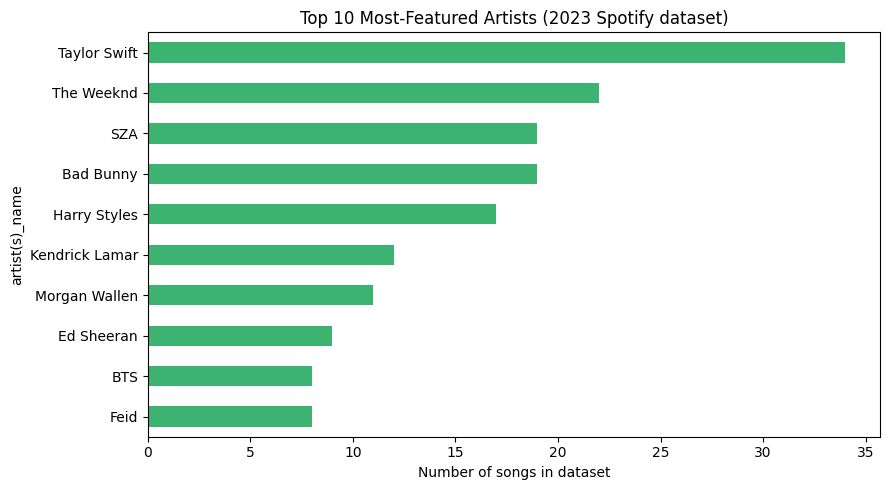

Number of unique artist(s) credits: 644


artist(s)_name
Taylor Swift      34
The Weeknd        22
Bad Bunny         19
SZA               19
Harry Styles      17
Kendrick Lamar    12
Morgan Wallen     11
Ed Sheeran         9
BTS                8
Feid               8
Name: count, dtype: int64

In [2]:
top_artists = df['artist(s)_name'].value_counts().head(10)

plt.figure(figsize=(9,5))
top_artists.sort_values().plot(kind='barh', color='mediumseagreen')
plt.xlabel('Number of songs in dataset')
plt.title('Top 10 Most-Featured Artists (2023 Spotify dataset)')
plt.tight_layout()
plt.show()

print(f"Number of unique artist(s) credits: {df['artist(s)_name'].nunique()}")
top_artists

**Description:** The `artist(s)_name` field is highly skewed - most artists appear only once or 
twice in the dataset, but a handful of artists show up far more often than everyone else. Taylor 
Swift is the most frequently-featured artist (34 songs), followed by The Weeknd, Bad Bunny, and SZA. 
This isn't really a feature we can "engineer" into a new song the way we can with BPM or key - it just 
tells us which artists were most prolific/charted most often in 2023, so we'll set this feature aside 
when we build our "engineered hit" criteria below.

## Step 3: BPM (Tempo)

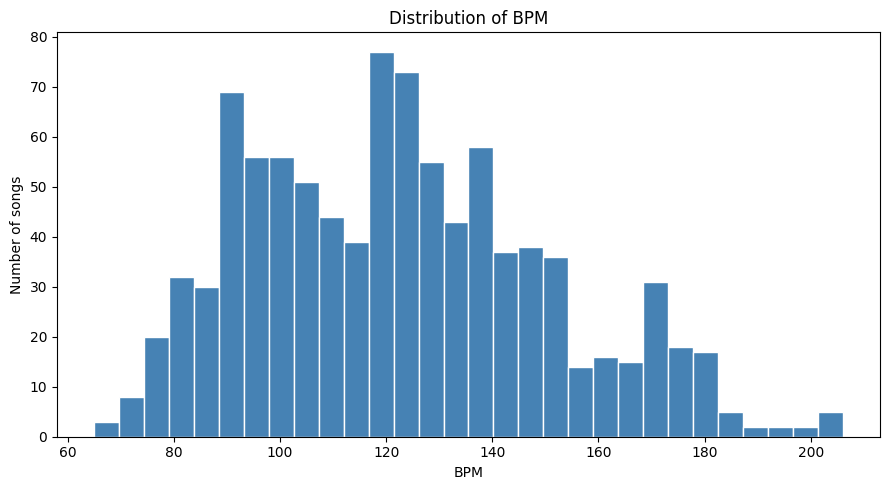

count    952.000000
mean     122.553571
std       28.069601
min       65.000000
25%       99.750000
50%      121.000000
75%      140.250000
max      206.000000
Name: bpm, dtype: float64
Mode: [120]


In [3]:
plt.figure(figsize=(9,5))
plt.hist(df['bpm'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('BPM')
plt.ylabel('Number of songs')
plt.title('Distribution of BPM')
plt.tight_layout()
plt.show()

print(df['bpm'].describe())
print(f"Mode: {df['bpm'].mode().tolist()}")

**Description:** BPM is roughly bell-shaped but with a long right tail (a handful of songs have 
very fast tempos, 200+ BPM). The middle 50% of songs (the interquartile range, Q1-Q3) fall between 
about **100 and 140 BPM**, with a median around 121 BPM and a mode of 120 BPM. 

**Proposed "hit" range: 100-140 BPM.**

## Step 4: Key

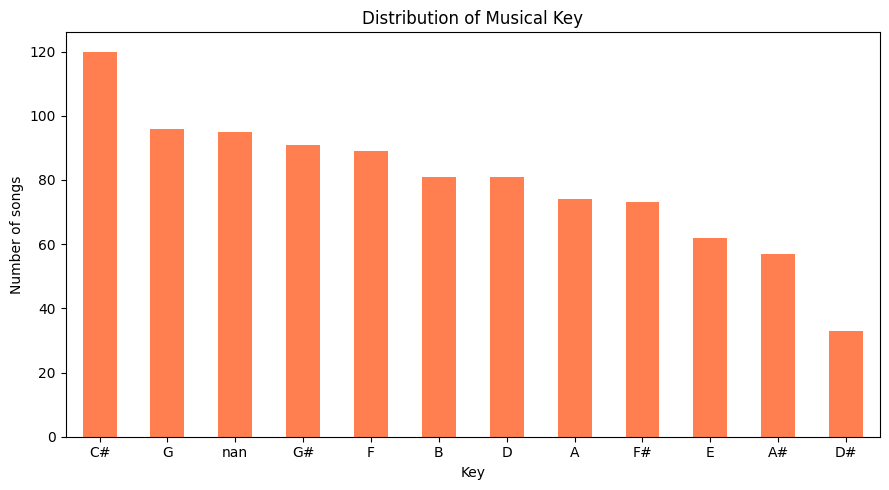

key
C#     120
G       96
NaN     95
G#      91
F       89
B       81
D       81
A       74
F#      73
E       62
A#      57
D#      33
Name: count, dtype: int64

In [4]:
key_counts = df['key'].value_counts(dropna=False)

plt.figure(figsize=(9,5))
key_counts.plot(kind='bar', color='coral')
plt.xlabel('Key')
plt.ylabel('Number of songs')
plt.title('Distribution of Musical Key')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

key_counts

**Description:** Key is categorical, and about 10% of songs are missing a key value (`NaN`). 
Among the songs with a labeled key, **C# is the single most common key** (120 songs), followed by G 
and G#. 

**Proposed "hit" value: C#.**

## Step 5: Mode

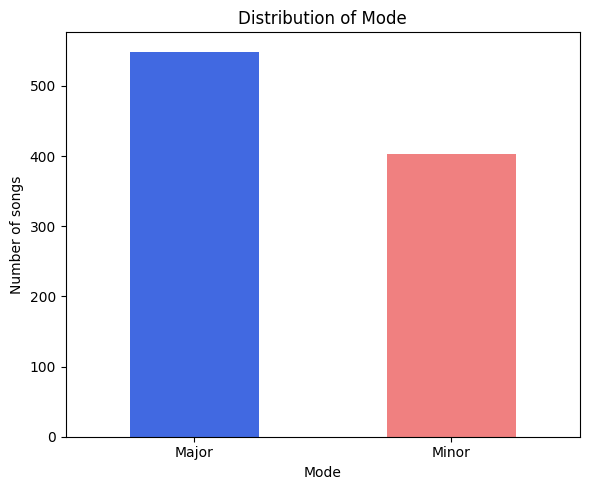

mode
Major    549
Minor    403
Name: count, dtype: int64

In [5]:
mode_counts = df['mode'].value_counts()

plt.figure(figsize=(6,5))
mode_counts.plot(kind='bar', color=['royalblue','lightcoral'])
plt.xlabel('Mode')
plt.ylabel('Number of songs')
plt.title('Distribution of Mode')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mode_counts

**Description:** Mode is binary (Major or Minor). About 58% of songs are in a **Major** key 
(550 songs) versus 42% in Minor (403 songs). Major is clearly the more common choice.

**Proposed "hit" value: Major.**

## Step 6: Danceability

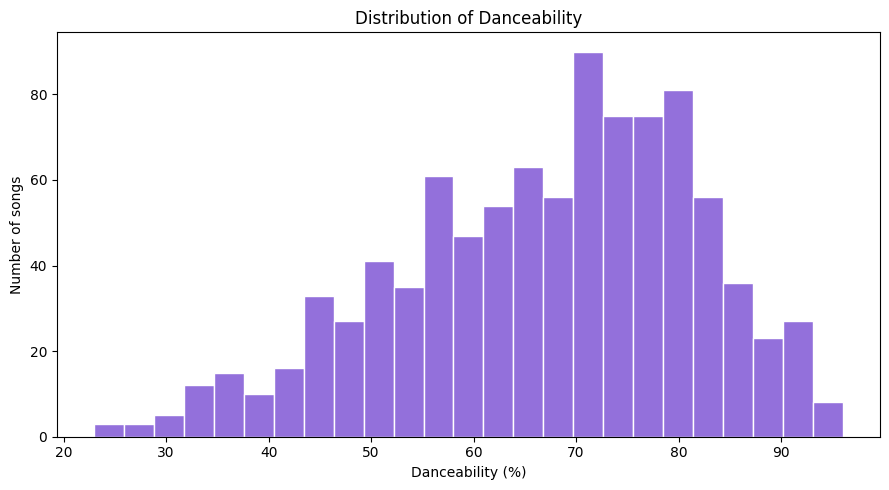

count    952.000000
mean      66.984244
std       14.631282
min       23.000000
25%       57.000000
50%       69.000000
75%       78.000000
max       96.000000
Name: danceability_%, dtype: float64


In [6]:
plt.figure(figsize=(9,5))
plt.hist(df['danceability_%'], bins=25, color='mediumpurple', edgecolor='white')
plt.xlabel('Danceability (%)')
plt.ylabel('Number of songs')
plt.title('Distribution of Danceability')
plt.tight_layout()
plt.show()

print(df['danceability_%'].describe())

**Description:** Danceability is left-skewed (piled up toward higher values), meaning most 2023 
hits are quite danceable. The interquartile range runs from about **57% to 78%**, with a median of 69%.

**Proposed "hit" range: 57%-78%.**

## Step 7: Energy

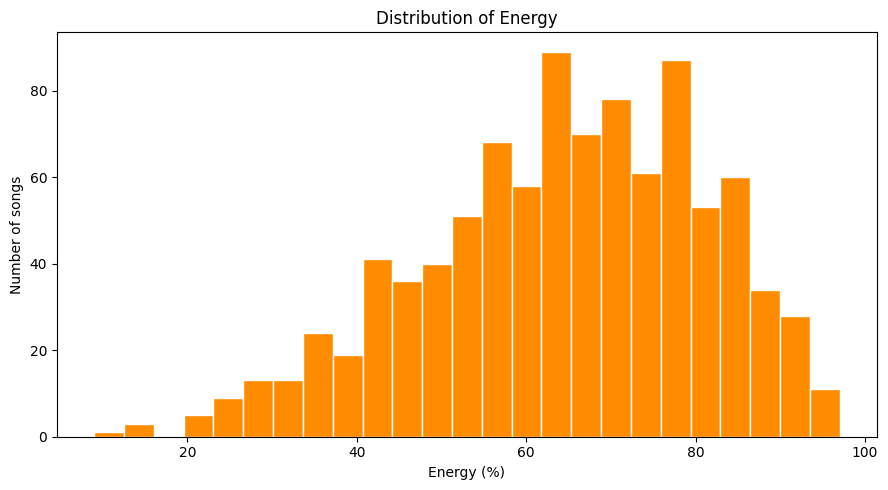

count    952.000000
mean      64.274160
std       16.558517
min        9.000000
25%       53.000000
50%       66.000000
75%       77.000000
max       97.000000
Name: energy_%, dtype: float64


In [7]:
plt.figure(figsize=(9,5))
plt.hist(df['energy_%'], bins=25, color='darkorange', edgecolor='white')
plt.xlabel('Energy (%)')
plt.ylabel('Number of songs')
plt.title('Distribution of Energy')
plt.tight_layout()
plt.show()

print(df['energy_%'].describe())

**Description:** Energy is also somewhat left-skewed, clustering in the mid-to-high range. The 
interquartile range runs from about **53% to 77%**, with a median of 66%.

**Proposed "hit" range: 53%-77%.**

## Step 8: Speechiness

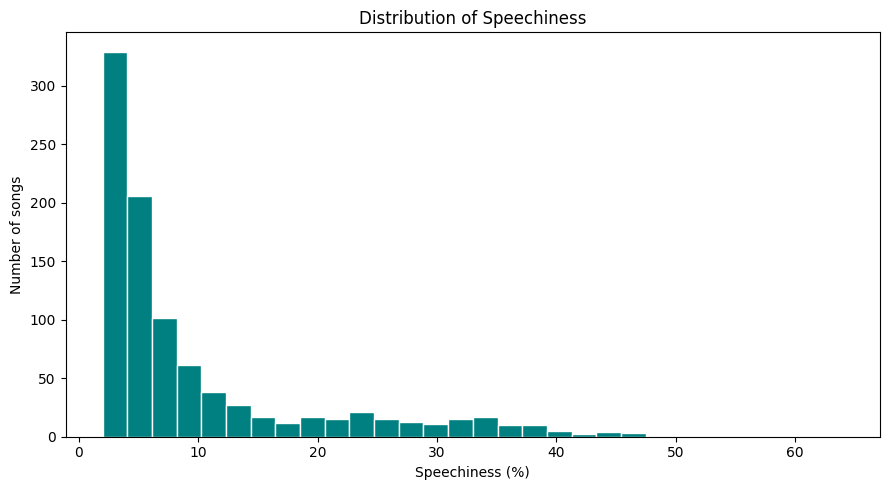

count    952.000000
mean      10.138655
std        9.915399
min        2.000000
25%        4.000000
50%        6.000000
75%       11.000000
max       64.000000
Name: speechiness_%, dtype: float64


In [8]:
plt.figure(figsize=(9,5))
plt.hist(df['speechiness_%'], bins=30, color='teal', edgecolor='white')
plt.xlabel('Speechiness (%)')
plt.ylabel('Number of songs')
plt.title('Distribution of Speechiness')
plt.tight_layout()
plt.show()

print(df['speechiness_%'].describe())

**Description:** Speechiness is heavily right-skewed - the vast majority of songs have very low 
speechiness (they're sung, not spoken/rapped), with only a few outliers scoring very high. The 
interquartile range runs from about **4% to 11%**, with a median of only 6%.

**Proposed "hit" range: 4%-11%.**

## Step 9: Acousticness

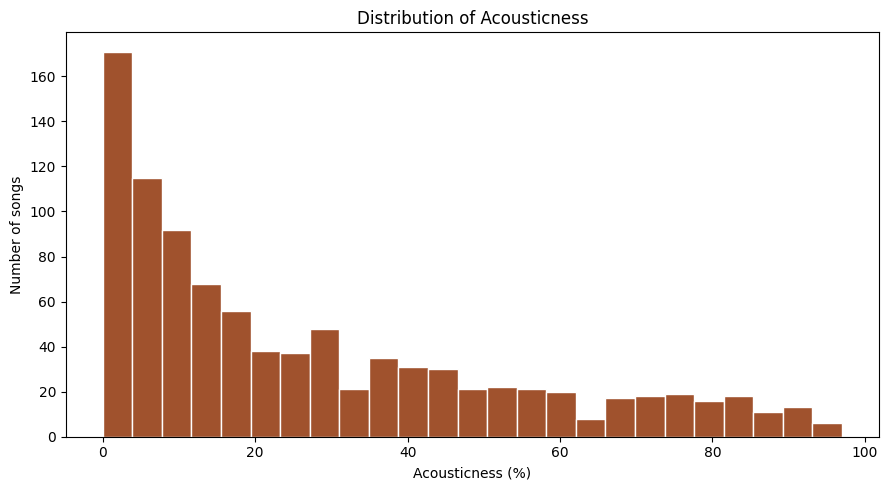

count    952.000000
mean      27.078782
std       26.001599
min        0.000000
25%        6.000000
50%       18.000000
75%       43.000000
max       97.000000
Name: acousticness_%, dtype: float64


In [9]:
plt.figure(figsize=(9,5))
plt.hist(df['acousticness_%'], bins=25, color='sienna', edgecolor='white')
plt.xlabel('Acousticness (%)')
plt.ylabel('Number of songs')
plt.title('Distribution of Acousticness')
plt.tight_layout()
plt.show()

print(df['acousticness_%'].describe())

**Description:** Acousticness is strongly right-skewed - most 2023 hits are produced/electronic 
rather than acoustic, so acousticness scores pile up near 0. The interquartile range runs from about 
**6% to 43%**, with a median of only 18%.

**Proposed "hit" range: 6%-43%.**

## Step 10: Our "Guaranteed Smash Hit" Formula

Putting all of the typical values together, here is the formula for our engineered smash hit:

| Feature | Typical / "Hit" Value |
|---|---|
| BPM | 100 - 140 |
| Key | C# |
| Mode | Major |
| Danceability | 57% - 78% |
| Energy | 53% - 77% |
| Speechiness | 4% - 11% |
| Acousticness | 6% - 43% |

(We're leaving Artist(s) name out of the formula, since it's not something you can "engineer" into a 
brand-new song - it just reflects who happened to release the most charting songs in 2023.)

## Step 11: Are There Any Real Songs That Match Our Formula?

In [10]:
criteria = (
    df['bpm'].between(100, 140) &
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    df['danceability_%'].between(57, 78) &
    df['energy_%'].between(53, 77) &
    df['speechiness_%'].between(4, 11) &
    df['acousticness_%'].between(6, 43)
)

engineered_hits = df[criteria]
print(f"Number of songs matching ALL criteria: {len(engineered_hits)}")
engineered_hits[['track_name', 'artist(s)_name', 'streams', 'bpm', 'key', 'mode',
                  'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']]

Number of songs matching ALL criteria: 2


,track_name,artist(s)_name,streams,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
518,Need To Know,Doja Cat,1042568408,130,C#,Major,66,61,7,30
660,Ginseng Strip 2002,Yung Lean,240769997,115,C#,Major,60,71,4,8


In [11]:
# How popular were these "engineered hit" songs compared to the rest of the dataset?
median_streams = df['streams'].median()

for _, row in engineered_hits.iterrows():
    percentile = (df['streams'] < row['streams']).mean() * 100
    print(f"{row['track_name']!r} by {row['artist(s)_name']}: "
          f"{row['streams']:,} streams (higher than {percentile:.1f}% of songs in the dataset)")

print(f"\nFor reference, the median song in the dataset has {median_streams:,.0f} streams.")

'Need To Know' by Doja Cat: 1,042,568,408 streams (higher than 84.5% of songs in the dataset)
'Ginseng Strip 2002' by Yung Lean: 240,769,997 streams (higher than 43.2% of songs in the dataset)

For reference, the median song in the dataset has 290,530,915 streams.


**Results:** Exactly **2 songs** in the dataset satisfy all seven criteria at once:

* **"Need To Know" by Doja Cat** - with just over 1 billion streams, this song beats about 85% of the 
  dataset. It really was a legitimate hit.
* **"Ginseng Strip 2002" by Yung Lean** - with about 241 million streams, this one only lands around 
  the 43rd percentile - roughly average, not a stand-out hit.

So the "engineered formula" approach is a mixed bag: it correctly found one very popular song, but the 
other match was only an average performer. Matching every "typical" feature is clearly not a guarantee 
of success - it's necessary at best, not sufficient.

## Step 12: Comparing to a Song We Know Was a Smash Hit

In [12]:
known_hit = df[df['track_name'] == 'Blinding Lights'].iloc[0]

comparison = pd.DataFrame({
    'Feature': ['BPM', 'Key', 'Mode', 'Danceability %', 'Energy %', 'Speechiness %', 'Acousticness %'],
    'Blinding Lights (The Weeknd)': [known_hit['bpm'], known_hit['key'], known_hit['mode'],
                                      known_hit['danceability_%'], known_hit['energy_%'],
                                      known_hit['speechiness_%'], known_hit['acousticness_%']],
    'Our "Engineered Hit" Range': ['100-140', 'C#', 'Major', '57-78', '53-77', '4-11', '6-43'],
})
comparison

,Feature,Blinding Lights (The Weeknd),"Our ""Engineered Hit"" Range"
0,BPM,171,100-140
1,Key,C#,C#
2,Mode,Major,Major
3,Danceability %,50,57-78
4,Energy %,80,53-77
5,Speechiness %,7,4-11
6,Acousticness %,0,6-43


In [13]:
streams_bl = known_hit['streams']
percentile_bl = (df['streams'] < streams_bl).mean() * 100
print(f"'Blinding Lights' has {streams_bl:,} streams - higher than {percentile_bl:.2f}% of all songs "
      f"in the dataset. It is the single most-streamed song here.")

'Blinding Lights' has 3,703,895,074 streams - higher than 99.89% of all songs in the dataset. It is the single most-streamed song here.


**Comparison:** "Blinding Lights" by The Weeknd is the most-streamed song in the entire dataset 
(3.7 billion streams, beating essentially 100% of other songs), so it's a great real-world "smash hit" 
to test our formula against.

* **Key (C#)** and **Mode (Major)** match our "hit" formula exactly.
* **Speechiness (7%)** also falls comfortably inside our proposed range (4%-11%).
* But **BPM (171)** is far above our proposed 100-140 range - it's a genuinely fast, up-tempo song.
* **Danceability (50%)** is actually *below* our proposed 57-78% range.
* **Energy (80%)** is slightly *above* our proposed 53-77% range.
* **Acousticness (0%)** is below our proposed 6-43% range (though close to it - the song is fully 
  produced/electronic, consistent with the overall trend we saw in Step 9).

**Takeaway:** The biggest smash hit in the dataset only matches about half of our "typical value" 
criteria. This confirms what Step 11 already hinted at: chasing the most statistically "typical" 
feature values is not a reliable recipe for a guaranteed hit. Real hit songs can - and do - break the 
mold on tempo, danceability, and energy while still becoming massively popular. Being "typical" might 
make a song unlikely to sound *bad*, but it doesn't make a song a guaranteed *hit*; other factors 
(artist fame, marketing, timing, virality, lyrics, cultural moment, etc.) matter at least as much as 
these seven audio features.